# COMP 352 Final Project

**Authors: Elbron Jackob, Cory Tamburrino, Anthony Frago, Benjamin Cavallari**

**Date: 04/29/2026**

### Student Dropout

### Full Dataset: https://www.kaggle.com/datasets/mohamedasak/online-learning-student-dropout-dataset

This dataset simulates behavioral and demographic data for 5,000 students enrolled in online learning platforms. It is designed for building and evaluating machine learning models that predict student dropout risk.



## Final Project Requirements

- **Data Importing and Pre-processing (100 Points)**
    - Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
    - Clean, wrangle, and handle missing data, duplicate data, etc.
    - Encode any categorical variables
    - Perform feature engineering on the dataset
    - Transform data appropriately using techniques such as aggregation, normalization, and feature construction
    - Reduce redundant data and perform need based discretization
- **Data Analysis and Visualization (100 Points)**
    - Identify categorical, ordinal, and numerical variables within data
    - Provide measures of centrality and distribution with visualizations
    - Diagnose for correlations between variables and determine independent and dependent variables
    - Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest
    - Create visualizations that allow for the discovery of insights in the data
- **Data Analytics (100 Points)**
    - Determine the need for a supervised or unsupervised learning method and identify dependent and independent variables
    - Choose and provide reasoning for the selected metric or metrics employed to assess your model.
    - Train, test, cross validate, and provide performance metrics for model results
    - Try multiple different types of algorithms to determine the best model for your dataset
    - Analyze your model performance
- **Presentation & Peer Evaluation (50 Points)**
    - In a 15 to 30 slide presentation, briefly explain the project workflow from the code and results from your Jupyter notebook. You must include information that is not found on each slides in the "Notes" section of your presentation. (See presentation example  for an outline of what the presentation should look like)
    - This presentation must be submitted by the university-scheduled final exam time for the course. It will not be presented in person; only the final project materials need to be submitted
    - State your findings from the data and provide the interpretation of results from your analysis at each stage in the project
    - Be sure to properly label visualizations in your presentation (axis labels, human readable column names, etc.) 
    - Complete the peer evaluation form  for each member of the group

Note: Matplotlib & scipy is not supported on python 3.15

## Table of Contents:
* [Environment Setup](#env-setup)
* [Data Importing and Pre-processing](#data-importing)
  * [Records and Columns](#records-and-columns)
  * [Column Data Types (Numeric vs Categorical)](#column-data-types-numeric-vs-categorical)
  * [Drop Unwanted Columns](#drop-unwanted-columns)
  * [Null Percentage per Column](#null-percentage-per-column)
  * [Class Balance Check](#class-balance-check)
  * [Check for Duplicate Student IDs](#check-for-duplicate-student-ids)
  * [Check for Outliers](#check-for-outliers)
  * [Feature Engineering: Enrollment Date](#feature-engineering-enrollment-date)
  * [Reducing Redundancy](#reducing-redundancy)
* [Data Analysis and Visualization](#data-vis)
  * [Additional EDA Visualizations](#additional-eda-visualizations)
* [Data Analytics](#data-analytics)
  * [Modeling Matrix: Features, Encoding, X, and y](#modeling-matrix-features-encoding-x-and-y)
  * [Classification Models](#classification-models-logistic-regression-decision-tree-random-forest-xgboost)
  * [Stratified 5-Fold Cross-Validation Summary](#stratified-5-fold-cross-validation-summary)
  * [Focused Hyperparameter Tuning](#focused-hyperparameter-tuning-for-top-models)
  * [ROC and Precision-Recall Curves](#roc-and-precision-recall-curves-cv-selected-baseline-vs-tuned)

## Environment Setup <a class="anchor" id="env-setup"></a>

First we must setup our environment. To do this, use the ```requirements.txt``` file to download the modules via ```pip```.

You may need to install setup tools. To do this run (Note you may need to change ```pip3``` to ```pip```):
```bash
pip3 install --upgrade pip setuptools wheel
```

and then run:
```bash
pip3 install -r env_setup/requirements.txt
```
```bash
conda env create -f env_setup/data_environment.yml
```
Then activate the environment by:
```bash
conda activate data_env
```

## Data Importing and Pre-processing <a class="anchor" id="data-importing"></a>

In [77]:
# Import libraries needed across the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay,
)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

# Import dataset
student_df = pd.read_csv("data/student_dropout_dataset.csv")

### Records and Columns

In [78]:
n_rows, n_cols = student_df.shape
print(f"Number of records (rows): {n_rows:,}")
print(f"Number of columns (fields): {n_cols}")

Number of records (rows): 5,000
Number of columns (fields): 15


### Column Data Types

In [79]:
num_mask = student_df.select_dtypes(include=[np.number]).columns
obj_mask = student_df.select_dtypes(include=["object", "category", "bool"]).columns

print("Numeric columns:", len(num_mask))
print(list(num_mask))
print()
print("Categorical columns:", len(obj_mask))
print(list(obj_mask))

feature_like_numeric = [c for c in num_mask if c not in {"label", "label_multiclass"}]
print()
print("Numeric columns excluding obvious targets (label, label_multiclass):", len(feature_like_numeric))
print(feature_like_numeric)

Numeric columns: 11
['age', 'exam_season', 'courses_enrolled', 'completed_assignments', 'completion_rate', 'login_frequency', 'last_activity_days_ago', 'forum_posts_count', 'dropout_score', 'label', 'label_multiclass']

Categorical columns: 4
['student_id', 'region', 'enroll_date', 'label_name']

Numeric columns excluding obvious targets (label, label_multiclass): 9
['age', 'exam_season', 'courses_enrolled', 'completed_assignments', 'completion_rate', 'login_frequency', 'last_activity_days_ago', 'forum_posts_count', 'dropout_score']


In [80]:
student_df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


### Drop Unwanted Columns

Dropping other potential target column to prevent data leakage: dropout_score, label_multiclass, label_name

In [81]:
student_df = student_df.drop(columns=["dropout_score", "label_multiclass", "label_name"])

In [82]:
student_df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,1
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,1
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,1
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,1


### Null Percentage per Column

In [83]:
null_pct = (student_df.isna().mean() * 100).round(4)
display(null_pct.to_frame("null_pct"))
print("Any missing values?", student_df.isna().any().any())

,null_pct
student_id,0.0
age,0.0
region,0.0
enroll_date,0.0
exam_season,0.0
courses_enrolled,0.0
completed_assignments,0.0
completion_rate,0.0
login_frequency,0.0
last_activity_days_ago,0.0


Any missing values? False


### Class Balance Check

Binary label (label) balance:
label
0    1704
1    3296
Name: count, dtype: int64

Class percentages (%):
label
0    34.08
1    65.92
Name: count, dtype: float64


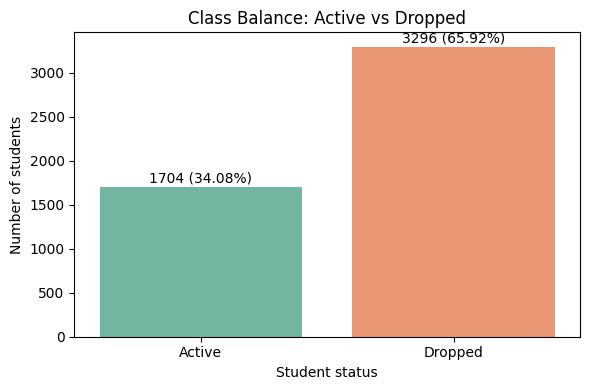

In [84]:
# Class counts and percentages (binary target)
class_counts = student_df["label"].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

print("Binary label (label) balance:")
print(class_counts)
print("\nClass percentages (%):")
print(class_pct)

plot_counts = class_counts.rename(index={0: "Active", 1: "Dropped"}).reset_index()
plot_counts.columns = ["status", "count"]

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=plot_counts, x="status", y="count", hue="status", palette="Set2", legend=False)
for i, row in plot_counts.iterrows():
    pct = class_pct.loc[0] if row["status"] == "Active" else class_pct.loc[1]
    ax.text(i, row["count"] + 20, f"{row['count']} ({pct}%)", ha="center", va="bottom", fontsize=10)
plt.title("Class Balance: Active vs Dropped")
plt.xlabel("Student status")
plt.ylabel("Number of students")
plt.tight_layout()
plt.show()


### Check for Duplicate Student IDs

Check for duplicate student_id values.


In [85]:
dup_id = student_df["student_id"].duplicated().sum()
nunique_id = student_df["student_id"].nunique()
print(f"Duplicate student_id: {dup_id}")
print(f"Unique student_id: {nunique_id}  (rows: {len(student_df)})")

Duplicate student_id: 0
Unique student_id: 5000  (rows: 5000)


### Check for Outliers

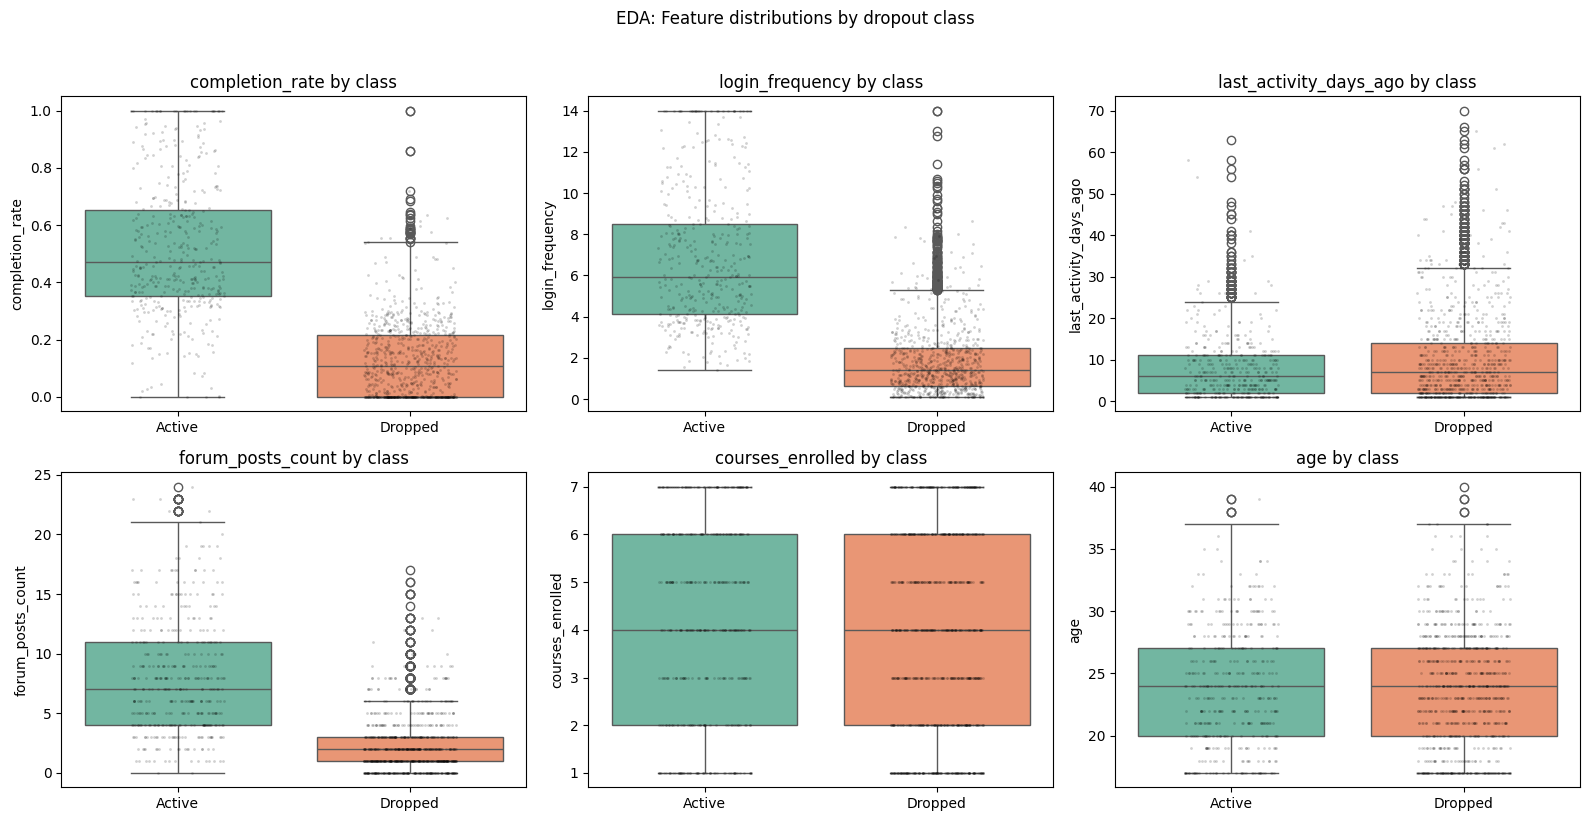

In [86]:
# Feature-by-class visualizations
plot_df = student_df.copy()
plot_df["status"] = plot_df["label"].map({0: "Active", 1: "Dropped"})

features_to_plot = [
    "completion_rate",
    "login_frequency",
    "last_activity_days_ago",
    "forum_posts_count",
    "courses_enrolled",
    "age",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, feature in zip(axes, features_to_plot):
    sns.boxplot(data=plot_df, x="status", y=feature, ax=ax, hue="status", palette="Set2", legend=False)
    sns.stripplot(
        data=plot_df.sample(min(1200, len(plot_df)), random_state=42),
        x="status",
        y=feature,
        ax=ax,
        color="black",
        alpha=0.18,
        size=2,
        jitter=0.2,
    )
    ax.set_title(f"{feature} by class")
    ax.set_xlabel("")

plt.suptitle("EDA: Feature distributions by dropout class", y=1.02)
plt.tight_layout()
plt.show()


### Note: Outlier Handling
Extreme values were retained because they represent meaningful student behavior associated with dropout risk rather than data-entry errors.

### Feature Engineering: Enrollment Date

Convert categorical type "enroll_date" to numeric type "enroll_month" (1-12). All entries have year 2024, and individual dates are potentially noisy.  Retaining enroll month to include seasonality in the model.

In [87]:
student_df["enroll_date"] = pd.to_datetime(student_df["enroll_date"])
student_df["enroll_month"] = student_df["enroll_date"].dt.month.astype(int)
student_df[["enroll_date", "enroll_month"]].head()

,enroll_date,enroll_month
0,2024-01-13,1
1,2024-05-05,5
2,2024-03-12,3
3,2024-12-12,12
4,2024-02-14,2


### Reducing Redundancy

completion_rate is strongly related to completed_assignments and courses_enrolled so keeping all three creates strong multicollinearity for linear models. We chose to keep completion_rate and courses_enrolled drop completed_assignments, which is the most redundant of the two count-based pieces given the rate is already in the data.


In [88]:
student_df = student_df.drop(columns=["completed_assignments"])
student_df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label,enroll_month
0,STU00001,26,Alexandria,2024-01-13,0,3,0.3571,5.29,10,5,0,1
1,STU00002,23,Amman,2024-05-05,0,6,0.0000,0.84,7,0,1,5
2,STU00003,17,Dubai,2024-03-12,0,3,0.0435,1.79,36,0,1,3
3,STU00004,23,Alexandria,2024-12-12,0,6,0.4396,0.78,9,0,1,12
4,STU00005,20,Baghdad,2024-02-14,0,5,0.2078,0.92,11,0,1,2


## Data Analysis and Visualization <a class="anchor" id="data-vis"></a>

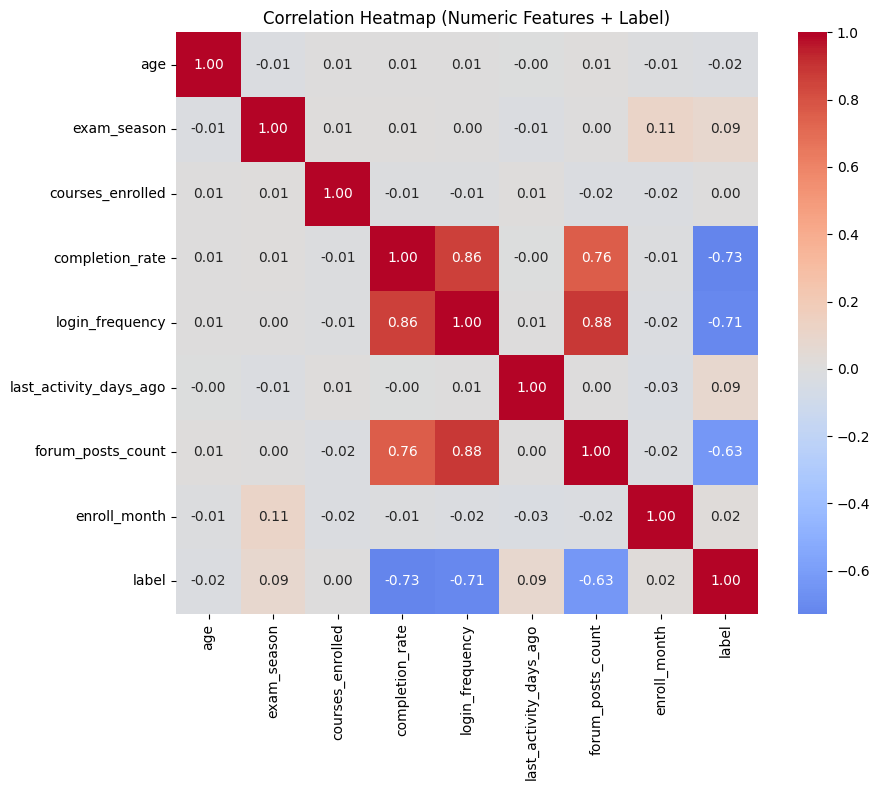

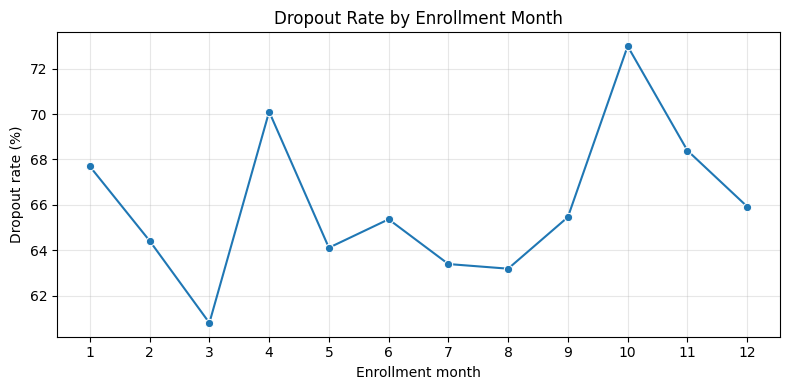

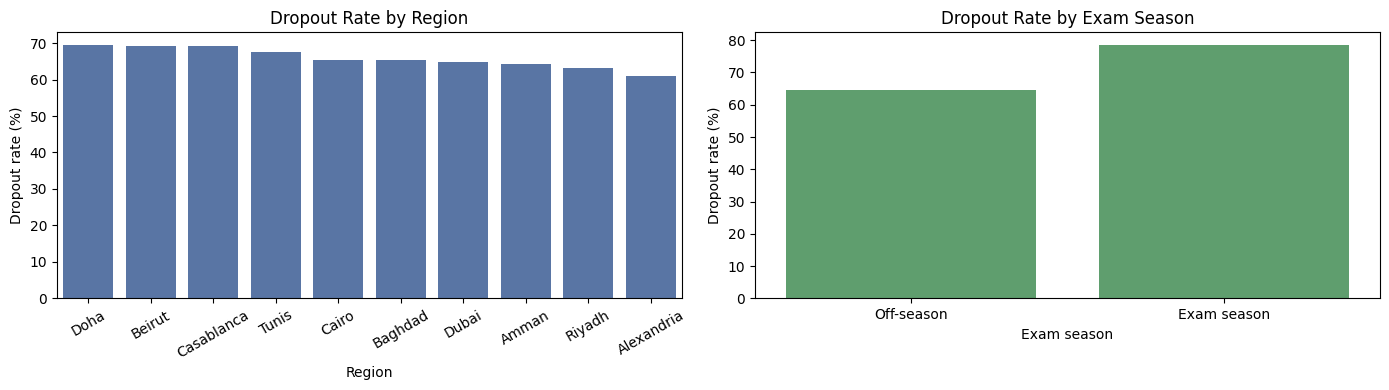

In [89]:
#Correlation heatmap (numeric features + label)
corr_cols = [
    "age",
    "exam_season",
    "courses_enrolled",
    "completion_rate",
    "login_frequency",
    "last_activity_days_ago",
    "forum_posts_count",
    "enroll_month",
    "label",
]

corr_matrix = student_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Numeric Features + Label)")
plt.tight_layout()
plt.show()

# Monthly dropout trend
monthly_dropout = (
    student_df.groupby("enroll_month", as_index=False)["label"]
    .mean()
    .rename(columns={"label": "dropout_rate"})
)
monthly_dropout["dropout_rate_pct"] = monthly_dropout["dropout_rate"] * 100

plt.figure(figsize=(8, 4))
ax = sns.lineplot(data=monthly_dropout, x="enroll_month", y="dropout_rate_pct", marker="o")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Enrollment month")
ax.set_ylabel("Dropout rate (%)")
ax.set_title("Dropout Rate by Enrollment Month")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Categorical vs target dropout rates
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

region_rates = (
    student_df.groupby("region", as_index=False)["label"].mean().sort_values("label", ascending=False)
)
region_rates["dropout_rate_pct"] = region_rates["label"] * 100
sns.barplot(data=region_rates, x="region", y="dropout_rate_pct", ax=axes[0], color="#4C72B0")
axes[0].set_title("Dropout Rate by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Dropout rate (%)")
axes[0].tick_params(axis="x", rotation=30)

season_rates = student_df.groupby("exam_season", as_index=False)["label"].mean()
season_rates["dropout_rate_pct"] = season_rates["label"] * 100
season_rates["exam_season_name"] = season_rates["exam_season"].map({0: "Off-season", 1: "Exam season"})
sns.barplot(data=season_rates, x="exam_season_name", y="dropout_rate_pct", ax=axes[1], color="#55A868")
axes[1].set_title("Dropout Rate by Exam Season")
axes[1].set_xlabel("Exam season")
axes[1].set_ylabel("Dropout rate (%)")

plt.tight_layout()
plt.show()


### Data Visualizations Analysis

- **Correlation heatmap:** The strongest relationships with dropout are : completion_rate (-0.728), login_frequency (-0.712), and forum_posts_count (-0.635). This suggests disengagement is a primary risk signal, while age and enroll_month are comparatively weak.
- **Dropout rate by month:** Dropout is highest in October (72.99%) and lowest in March (60.81%), a spread of 12.18%. That pattern suggests seasonality worth using for early-risk planning.
- **Dropout vs categorical features:** exam_season shows a large difference (78.51% vs 64.61%, +13.90%), and region rates vary by 8.63 pp (Doha highest at 69.48%, Alexandria lowest at 60.85%).


## Data Analytics <a class="anchor" id="data-analytics"></a>

### Modeling Matrix: Features, Encoding, X, and y

- Numeric features: age, exam_season, courses_enrolled, completion_rate, login_frequency, last_activity_days_ago, forum_posts_count, enroll_month.
- Target: label.
- student_id: excluded from features
- region: kept as a raw categorical feature in X; one-hot encoding is performed inside sklearn pipelines to avoid leakage.


In [90]:
numeric_features = [
    "age",
    "exam_season",
    "courses_enrolled",
    "completion_rate",
    "login_frequency",
    "last_activity_days_ago",
    "forum_posts_count",
    "enroll_month",
]
categorical_features = ["region"]

# Keep categorical columns raw; encode later inside CV/train pipelines to prevent leakage.
X = student_df[numeric_features + categorical_features].copy()
y = student_df["label"].copy()
feature_cols = list(X.columns)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of input features:", len(feature_cols))
X.head()


X shape: (5000, 9)
y shape: (5000,)
Number of input features: 9


,age,exam_season,courses_enrolled,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,enroll_month,region
0,26,0,3,0.3571,5.29,10,5,1,Alexandria
1,23,0,6,0.0000,0.84,7,0,5,Amman
2,17,0,3,0.0435,1.79,36,0,3,Dubai
3,23,0,6,0.4396,0.78,9,0,12,Alexandria
4,20,0,5,0.2078,0.92,11,0,2,Baghdad


### Classification Models: Logistic Regression, Decision Tree, Random Forest, XGBoost

Set up four baseline classifiers and ensures the test set is held out until the end to prevent data leakage.
- First create a stratified train/test split
- Keep the test set untouched until the final post-tuning evaluation
- Run all baseline comparison and tuning with stratified 5-fold CV on the training split only


In [91]:
# Preprocessing pipelines (categorical features encoded inside each CV fold / model fit).
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Holdout split: test set is locked until the end.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# 5-fold CV object used for baseline comparison and tuning on training data only.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scale_pos_weight = negatives / positives (computed from training split only).
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocess", preprocess_lr),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "Decision Tree": Pipeline(
        steps=[
            ("preprocess", preprocess_tree),
            ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced")),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", preprocess_tree),
            ("model", RandomForestClassifier(
                n_estimators=400,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("preprocess", preprocess_tree),
            ("model", XGBClassifier(
                n_estimators=400,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                scale_pos_weight=scale_pos_weight,
            )),
        ]
    ),
}

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Test set is held out and not used until final evaluation.")


Train shape: (4000, 9) | Test shape: (1000, 9)
Test set is held out and not used until final evaluation.


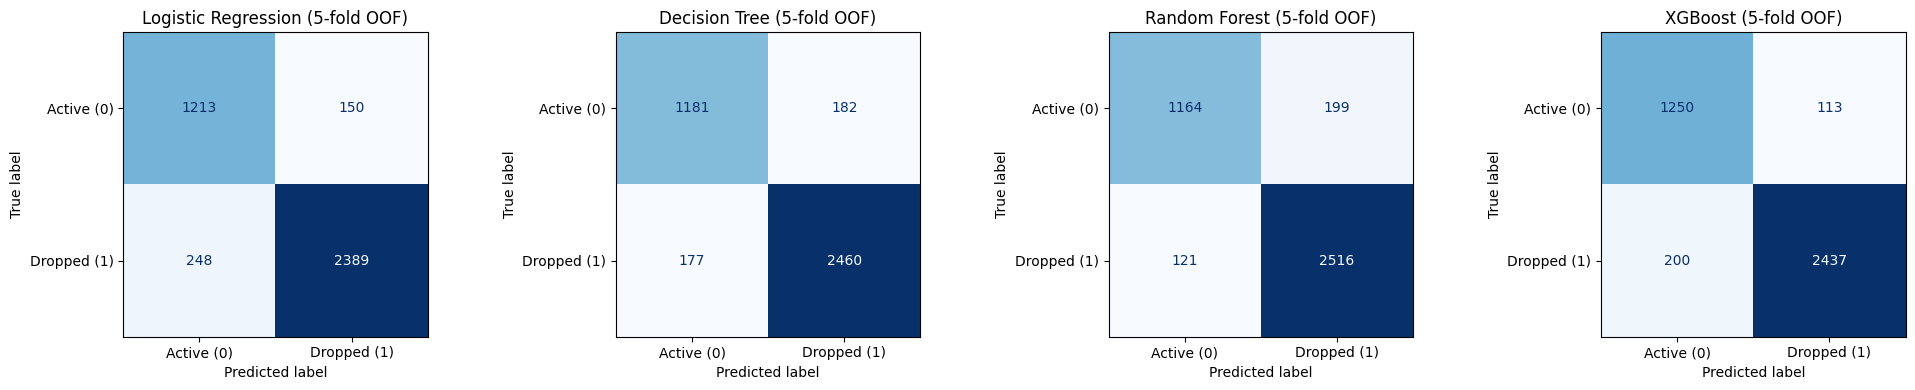

In [92]:
# Single 5-fold pass per model on training split to collect fold metrics for CV summary and out-of-fold predictions for confusion matrices
scoring_names = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
cv_rows = []
oof_predictions = {}
oof_scores = {}

for name, model in models.items():
    y_pred_oof = np.zeros(len(y_train), dtype=int)
    y_score_oof = np.zeros(len(y_train), dtype=float)
    fold_metrics = {metric: [] for metric in scoring_names}

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        fold_model = clone(model)
        fold_model.fit(X_fold_train, y_fold_train)

        y_pred_fold = fold_model.predict(X_fold_val)
        y_score_fold = fold_model.predict_proba(X_fold_val)[:, 1]

        y_pred_oof[val_idx] = y_pred_fold
        y_score_oof[val_idx] = y_score_fold

        fold_metrics["accuracy"].append(accuracy_score(y_fold_val, y_pred_fold))
        fold_metrics["precision"].append(precision_score(y_fold_val, y_pred_fold, zero_division=0))
        fold_metrics["recall"].append(recall_score(y_fold_val, y_pred_fold, zero_division=0))
        fold_metrics["f1"].append(f1_score(y_fold_val, y_pred_fold, zero_division=0))
        fold_metrics["roc_auc"].append(roc_auc_score(y_fold_val, y_score_fold))
        fold_metrics["pr_auc"].append(average_precision_score(y_fold_val, y_score_fold))

    row = {"model": name}
    for metric_name in scoring_names:
        row[f"{metric_name}_mean"] = np.mean(fold_metrics[metric_name])
        row[f"{metric_name}_std"] = np.std(fold_metrics[metric_name])
    cv_rows.append(row)

    oof_predictions[name] = y_pred_oof
    oof_scores[name] = y_score_oof

cv_results_df = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)

# Confusion matrices from OOF predictions generated above
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_train,
        oof_predictions[name],
        display_labels=["Active (0)", "Dropped (1)"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"{name} (5-fold OOF)")

plt.tight_layout()
plt.show()


### Stratified 5-Fold Cross-Validation Summary for Baseline Results


Stratified 5-fold CV on training split (mean ± std):


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Random Forest,0.9200,0.0108,0.9267,0.0075,0.9541,0.0140,0.9402,0.0083,0.9804,0.0043,0.9896,0.0021
1,XGBoost,0.9218,0.0127,0.9557,0.0053,0.9242,0.0210,0.9395,0.0104,0.9815,0.0046,0.9906,0.0023
2,Decision Tree,0.9103,0.0105,0.9312,0.0102,0.9329,0.0086,0.9320,0.0078,0.8997,0.0125,0.9130,0.0106
3,Logistic Regression,0.9005,0.0142,0.9409,0.0069,0.9060,0.0168,0.9230,0.0114,0.9646,0.0085,0.9817,0.0043


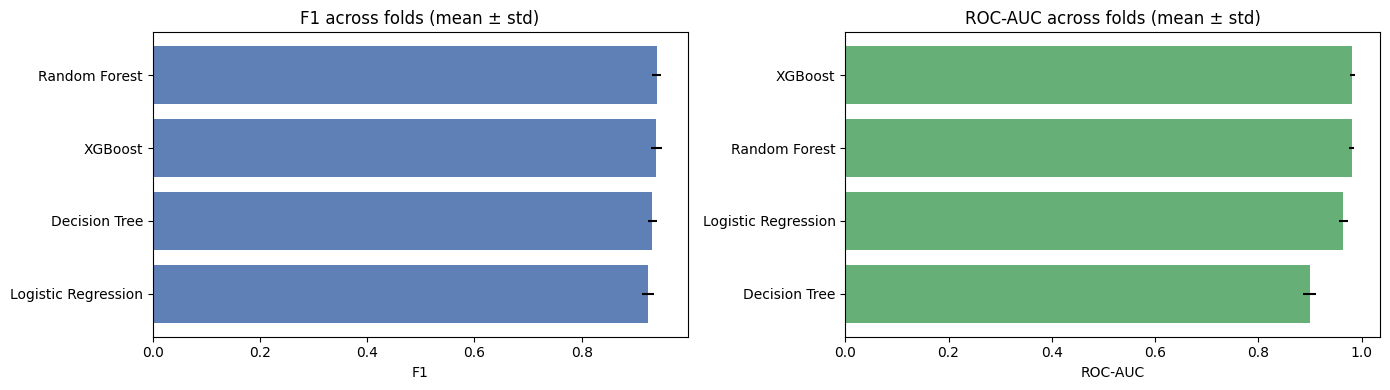

In [93]:
display_cols = [
    "model",
    "accuracy_mean", "accuracy_std",
    "precision_mean", "precision_std",
    "recall_mean", "recall_std",
    "f1_mean", "f1_std",
    "roc_auc_mean", "roc_auc_std",
    "pr_auc_mean", "pr_auc_std",
]

print("Stratified 5-fold CV on training split (mean ± std):")
display(cv_results_df[display_cols].round(4))

# Visualization of stability and central tendency
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

f1_sorted = cv_results_df.sort_values("f1_mean", ascending=True)
axes[0].barh(f1_sorted["model"], f1_sorted["f1_mean"], xerr=f1_sorted["f1_std"], color="#4C72B0", alpha=0.9)
axes[0].set_title("F1 across folds (mean ± std)")
axes[0].set_xlabel("F1")

roc_sorted = cv_results_df.sort_values("roc_auc_mean", ascending=True)
axes[1].barh(roc_sorted["model"], roc_sorted["roc_auc_mean"], xerr=roc_sorted["roc_auc_std"], color="#55A868", alpha=0.9)
axes[1].set_title("ROC-AUC across folds (mean ± std)")
axes[1].set_xlabel("ROC-AUC")

plt.tight_layout()
plt.show()


### CV Results Interpretation

- The confusion matrices show each model’s error pattern on unseen validation folds. Diagonally strong matrices indicate most students are correctly classified, with remaining errors split between missed dropouts (false negatives) and over-flagged active students (false positives).

- The F1 plot summarizes threshold-based classification quality (precision-recall balance) across folds, while the ROC-AUC plot summarizes ranking/separation quality across thresholds.
- High means and small standard deviations in both plots indicate consistently strong, stable performance across folds rather than a result driven by one favorable split.
- Because these results come from training-split cross-validation, they are used for model comparison and selection before the held-out test set is touched.

### Focused Hyperparameter Tuning for Top Models

Perform hyperparameter tuning on the top performing models by F1 and ROC-AUC (Random Forest and XGBoost) using stratified 5-fold CV on the training split only, then evaluate tuned models on the untouched holdout test set at the end.

In [94]:
def evaluate_on_test(model, model_name):
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
        "pr_auc": average_precision_score(y_test, y_score) if y_score is not None else np.nan,
    }

tuned_models = {}
tuning_rows = []

# Tune Random Forest with 5-fold CV on training split
rf_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocess", preprocess_tree),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
        ]
    ),
    param_distributions={
        "model__n_estimators": randint(200, 900),
        "model__max_depth": [None, 4, 6, 8, 10, 12],
        "model__min_samples_split": randint(2, 16),
        "model__min_samples_leaf": randint(1, 8),
        "model__max_features": ["sqrt", "log2", None],
    },
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
tuned_models["Random Forest (Tuned)"] = rf_search.best_estimator_
tuning_rows.append(
    {
        "model": "Random Forest (Tuned)",
        "best_cv_f1": rf_search.best_score_,
        "best_params": rf_search.best_params_,
    }
)

# Tune XGBoost with 5-fold CV on training split
xgb_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocess", preprocess_tree),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                scale_pos_weight=scale_pos_weight,
            )),
        ]
    ),
    param_distributions={
        "model__n_estimators": randint(200, 900),
        "model__max_depth": randint(3, 9),
        "model__learning_rate": uniform(0.01, 0.2),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__min_child_weight": randint(1, 8),
        "model__gamma": uniform(0, 0.4),
    },
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
tuned_models["XGBoost (Tuned)"] = xgb_search.best_estimator_
tuning_rows.append(
    {
        "model": "XGBoost (Tuned)",
        "best_cv_f1": xgb_search.best_score_,
        "best_params": xgb_search.best_params_,
    }
)

tuning_results_df = pd.DataFrame(tuning_rows)
print("Best hyperparameters from randomized 5-fold CV (training split):")
display(tuning_results_df)

# Final holdout test evaluation happens here (first test-set usage in this section).
if tuned_models:
    tuned_test_df = pd.DataFrame(
        [evaluate_on_test(m, n) for n, m in tuned_models.items()]
    ).sort_values("f1", ascending=False).reset_index(drop=True)

    print("Post-tuning results on held-out test set:")
    display(tuned_test_df.round(4))


Best hyperparameters from randomized 5-fold CV (training split):


,model,best_cv_f1,best_params
0,Random Forest (Tuned),0.944989,"{'model__max_depth': None, 'model__max_feature..."
1,XGBoost (Tuned),0.941475,{'model__colsample_bytree': 0.9329770563201687...


Post-tuning results on held-out test set:


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest (Tuned),0.924,0.9519,0.9317,0.9417,0.9814,0.9905
1,XGBoost (Tuned),0.918,0.9501,0.9241,0.9369,0.9796,0.9898


### ROC and Precision-Recall Curves (Test Set)

Plot final holdout-test curves for the best CV baseline model and both tuned models.


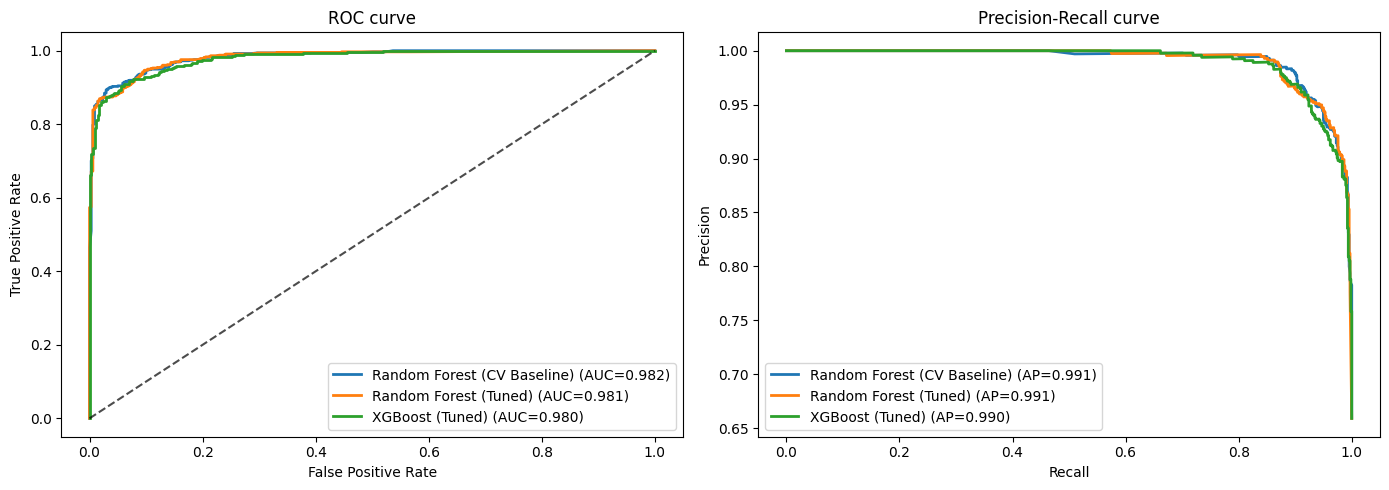

In [95]:
# Choose strongest baseline from CV on training split (no test-set selection).
baseline_best_name = cv_results_df.sort_values("f1_mean", ascending=False).iloc[0]["model"]
baseline_best_model = models[baseline_best_name]
baseline_best_model.fit(X_train, y_train)

models_for_curve = {f"{baseline_best_name} (CV Baseline)": baseline_best_model}
models_for_curve.update(tuned_models)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models_for_curve.items():
    y_score = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_val:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_val = average_precision_score(y_test, y_score)
    axes[1].plot(recall, precision, linewidth=2, label=f"{name} (AP={pr_val:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.7)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


### Final Interpretation and Project Conclusion

- The final ROC and Precision-Recall curves summarize holdout-test performance for the tuned Random Forest and tuned XGBoost models.

- Random Forest comparison: baseline CV means were F1 = 0.9402 and ROC-AUC mean = 0.9804; after tuning, performance improved to **CV best F1 = 0.9450** and holdout **ROC-AUC = 0.9814**.

- **XGBoost comparison:** baseline CV means were **F1 = 0.9395** and **ROC-AUC mean = 0.9815**; after tuning, performance improved to **CV best F1 = 0.9415** and holdout **ROC-AUC = 0.9796**.

- Overall, both tuned models remained very strong and stable. Tuned Random Forest showed a clearer gain over its baseline on both threshold-based quality (F1) and ranking quality (ROC-AUC), while tuned XGBoost improved F1 and stayed near baseline ROC-AUC performance.

Overall, this project built a leakage-aware dropout prediction pipeline from preprocessing and EDA through cross-validated modeling, targeted hyperparameter tuning, and final holdout evaluation. The results show that tree-based tuned models are effective choices for identifying dropout risk and provide a strong foundation for early-warning support in online learning environments.